# fig1_clone - Part 3/3\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


In [26]:
import numpy as np
import pandas as pd

# ============================================================
# ===== 1) 读数据（按你现有文件名）=====
# ============================================================
sc_path    = "wb_alltype_sc_subset_zj_1_2.5_42_1209.npy"
names_path = "wb_alltype_sc_subset_names_zj_1_2.5_42_1209.npy"
csv_path   = "Metadata_PFC_MOp.csv"

sc = np.load(sc_path)
names = np.load(names_path, allow_pickle=True)
names = names.tolist() if isinstance(names, np.ndarray) else list(names)
names = np.asarray([str(x) for x in names], dtype=str)

df = pd.read_csv(csv_path)

# ============================================================
# ===== 2) 列名兼容（id / clone / layer / clone_region）=====
# ============================================================
if "name" in df.columns:
    id_col = "name"
elif "Unnamed: 0" in df.columns:
    id_col = "Unnamed: 0"
else:
    raise ValueError("CSV 里找不到 neuron id 列（尝试 'name' / 'Unnamed: 0'）。")

clone_region_col = None
for cand in ["Clone_region", "clone_region", "CLONE_REGION"]:
    if cand in df.columns:
        clone_region_col = cand
        break
if clone_region_col is None:
    raise ValueError("CSV 里找不到 Clone_region 列（Clone_region/clone_region/CLONE_REGION）。")

need_cols = {"clone", "Layer", clone_region_col}
miss = need_cols - set(df.columns)
if miss:
    raise ValueError(f"CSV 缺少列: {miss}")

# ============================================================
# ===== 3) 对齐到 sc/names 顺序：clone / layer / region =====
# ============================================================
meta = df.copy()
meta[id_col] = meta[id_col].astype(str)
meta = meta.set_index(id_col)

clone_arr  = meta.reindex(names)["clone"].to_numpy()
layer_arr  = meta.reindex(names)["Layer"].astype(str).to_numpy()
region_arr = meta.reindex(names)[clone_region_col].astype(str).to_numpy()

valid = ~pd.isna(clone_arr)
print(f"总节点数: {len(names)}")
print(f"按 clone 匹配到的节点数: {int(valid.sum())}")
print(f"clone 数: {pd.unique(clone_arr[valid]).size}")

# ============================================================
# ===== 4) 按 clone：找最大弱连通子图(LCC)；只保留 LCC>=6 =====
#          统计：全图/2_3层内/5&6层内/2_3<->5&6层间 的 单向/双向/频率
#          频率分母 = 单向pair + 双向pair（只统计“有边的pair”）
#          层内节点数<3 -> NA；层间任一侧<3 -> NA
# ============================================================
thr = 0.0
records = []

clones = pd.unique(clone_arr[valid])
for cl in clones:
    idxs = np.flatnonzero((clone_arr == cl) & valid)
    if idxs.size < 6:
        continue

    A_sub = sc[np.ix_(idxs, idxs)]
    B = (A_sub > thr)
    np.fill_diagonal(B, False)

    # ---------- 找最大弱连通分量（把有向当无向）----------
    U = B | B.T
    n0 = U.shape[0]
    visited = np.zeros(n0, dtype=bool)
    best_nodes = []
    for s in range(n0):
        if visited[s]:
            continue
        stack = [s]
        visited[s] = True
        comp = []
        while stack:
            v = stack.pop()
            comp.append(v)
            for u in np.flatnonzero(U[v]):
                if not visited[u]:
                    visited[u] = True
                    stack.append(u)
        if len(comp) > len(best_nodes):
            best_nodes = comp

    lcc_n = len(best_nodes)
    if lcc_n < 6:
        continue

    best_nodes = np.asarray(best_nodes, dtype=int)
    B_lcc = B[np.ix_(best_nodes, best_nodes)]

    # ---------- layer 归一化到 2_3 / 5 / 6 / other ----------
    layers_raw = layer_arr[idxs][best_nodes]
    layers_norm = []
    for L in layers_raw:
        s = str(L).strip().replace("L", "").replace("layer", "").replace("Layer", "")
        s = s.replace("/", "_").replace("-", "_").replace(" ", "")
        if ("2_3" in s) or ("2_3" in s.replace("__", "_")) or (("2" in s) and ("3" in s)):
            layers_norm.append("2_3")
        elif "5" in s:
            layers_norm.append("5")
        elif "6" in s:
            layers_norm.append("6")
        else:
            layers_norm.append("other")
    layers_norm = np.asarray(layers_norm, dtype=object)

    idx_23 = np.flatnonzero(layers_norm == "2_3")
    idx_56 = np.flatnonzero((layers_norm == "5") | (layers_norm == "6"))

    # ---------- 一个小工具：算某个 Bsub 的 单向/双向 + 频率（pair口径）----------
    def _within(Bsub):
        n = Bsub.shape[0]
        if n < 2:
            return (np.nan, np.nan, np.nan, np.nan)
        tri = np.triu(np.ones((n, n), dtype=bool), 1)
        bi = int(((Bsub & Bsub.T)[tri]).sum())
        uni = int(((Bsub ^ Bsub.T)[tri]).sum())
        den = uni + bi
        return (uni, bi, (uni / den) if den else np.nan, (bi / den) if den else np.nan)

    # ---------- 全图（LCC）----------
    uni_all, bi_all, f_uni_all, f_bi_all = _within(B_lcc)

    # ---------- 2_3 层内 ----------
    if idx_23.size < 3:
        uni_23 = bi_23 = f_uni_23 = f_bi_23 = np.nan
    else:
        uni_23, bi_23, f_uni_23, f_bi_23 = _within(B_lcc[np.ix_(idx_23, idx_23)])

    # ---------- 5&6 层内 ----------
    if idx_56.size < 3:
        uni_56 = bi_56 = f_uni_56 = f_bi_56 = np.nan
    else:
        uni_56, bi_56, f_uni_56, f_bi_56 = _within(B_lcc[np.ix_(idx_56, idx_56)])

    # ---------- 2_3 vs 5/6 层间 ----------
    if idx_23.size < 3 or idx_56.size < 3:
        uni_23_56 = bi_23_56 = f_uni_23_56 = f_bi_23_56 = np.nan
    else:
        AB = B_lcc[np.ix_(idx_23, idx_56)]      # 2_3 -> 5/6
        BA = B_lcc[np.ix_(idx_56, idx_23)].T    # 5/6 -> 2_3（转置后对齐到同一对）
        bi_23_56 = int((AB & BA).sum())
        uni_23_56 = int((AB ^ BA).sum())
        den = uni_23_56 + bi_23_56
        f_uni_23_56 = (uni_23_56 / den) if den else np.nan
        f_bi_23_56  = (bi_23_56  / den) if den else np.nan

    # ---------- region：沿用你之前“取第一个有效 Clone_region” ----------
    regs = region_arr[idxs]
    regs = regs[(regs != "nan") & (regs != "None") & (regs != "")]  # 注意：这里保留你原先口径（不做投票）
    region = regs[0] if regs.size else ""

    records.append({
        "clone": cl,
        "region": region,
        "lcc_n": int(lcc_n),
        "n_23": int(idx_23.size),
        "n_56": int(idx_56.size),

        "uni_all": uni_all, "bi_all": bi_all, "f_uni_all": f_uni_all, "f_bi_all": f_bi_all,
        "uni_23": uni_23, "bi_23": bi_23, "f_uni_23": f_uni_23, "f_bi_23": f_bi_23,
        "uni_56": uni_56, "bi_56": bi_56, "f_uni_56": f_uni_56, "f_bi_56": f_bi_56,
        "uni_23_56": uni_23_56, "bi_23_56": bi_23_56, "f_uni_23_56": f_uni_23_56, "f_bi_23_56": f_bi_23_56,
    })

# ============================================================
# ===== 5) 展示结果（不存文件）=====
# ============================================================
res = pd.DataFrame(records)
print(f"\n保留下来的 clone 数（LCC>=6）: {len(res)}")
if len(res) == 0:
    raise ValueError("没有任何 clone 满足 LCC>=6（或数据没对齐成功）。")

# ---- 大脑区分组（PFC=ACA/PL/FRP/ORB；MOp/MOs）----
g = pd.Series([np.nan] * len(res), index=res.index, dtype=object)
r = res["region"].astype(str)
g[r.str.startswith(("ACA", "PL", "FRP", "ORB"))] = "PFC"
g[r.str.startswith("MOp")] = "MOp"
g[r.str.startswith("MOs")] = "MOs"
res["group"] = g

# ---- 快速预览：前20个 clone ----
cols_show = ["clone","region","group","lcc_n","n_23","n_56",
             "uni_all","bi_all","f_uni_all","f_bi_all",
             "uni_23","bi_23","f_uni_23","f_bi_23",
             "uni_56","bi_56","f_uni_56","f_bi_56",
             "uni_23_56","bi_23_56","f_uni_23_56","f_bi_23_56"]
print("\n=== 每个 clone 的统计（前20行）===")
print(res[cols_show].head(20).to_string(index=False))

# ---- 分组汇总：均值（可按需改成 median 等）----
use = res[res["group"].isin(["PFC", "MOp", "MOs"])].copy()
metrics = ["f_bi_all","f_bi_23","f_bi_56","f_bi_23_56","bi_all","uni_all","lcc_n","n_23","n_56"]
print("\n=== 三组汇总：均值（自动跳过 NA）===")
print(use.groupby("group")[metrics].mean(numeric_only=True).round(4))

总节点数: 751
按 clone 匹配到的节点数: 751
clone 数: 92

保留下来的 clone 数（LCC>=6）: 78

=== 每个 clone 的统计（前20行）===
        clone region group  lcc_n  n_23  n_56  uni_all  bi_all  f_uni_all  f_bi_all  uni_23  bi_23  f_uni_23  f_bi_23  uni_56  bi_56  f_uni_56  f_bi_56  uni_23_56  bi_23_56  f_uni_23_56  f_bi_23_56
 ACA-062301-1    ACA   PFC      6     2     4        6       1   0.857143  0.142857     NaN    NaN       NaN      NaN     2.0    1.0  0.666667 0.333333        NaN       NaN          NaN         NaN
 ACA-070301-2    ACA   PFC      7     5     2        6       7   0.461538  0.538462     3.0    7.0  0.300000 0.700000     NaN    NaN       NaN      NaN        NaN       NaN          NaN         NaN
ACA-071502-03    ACA   PFC      9     8     1       11      14   0.440000  0.560000    10.0   13.0  0.434783 0.565217     NaN    NaN       NaN      NaN        NaN       NaN          NaN         NaN
 ACA-081201-1     PL   PFC      7     4     3        8       9   0.470588  0.529412     1.0    4.0  0.200000 0.

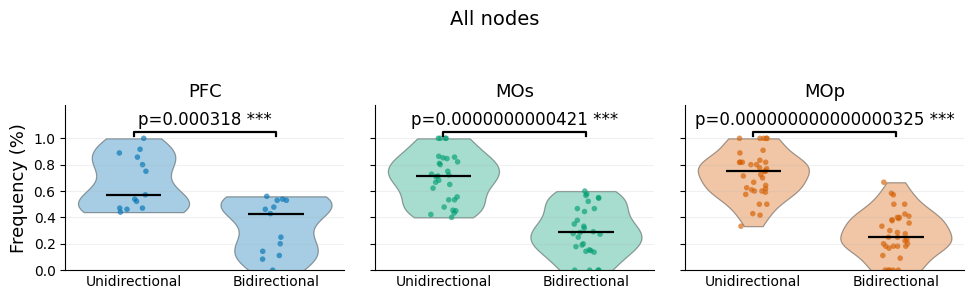

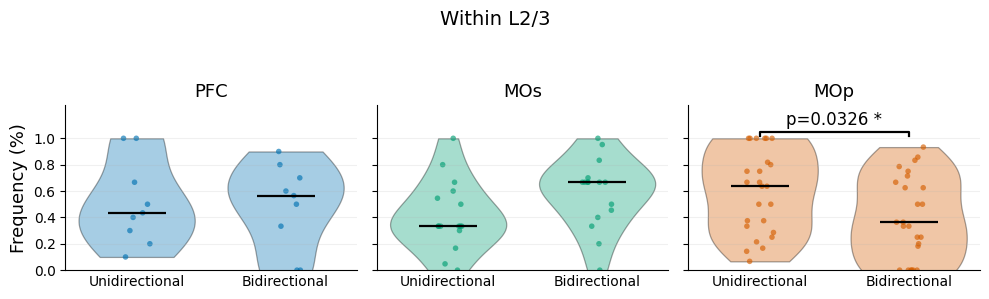

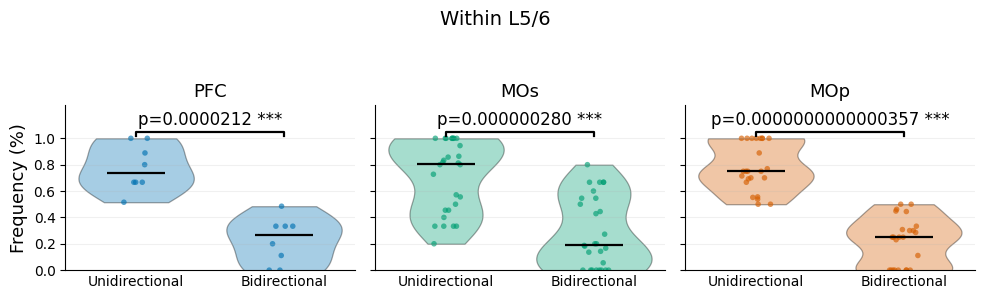

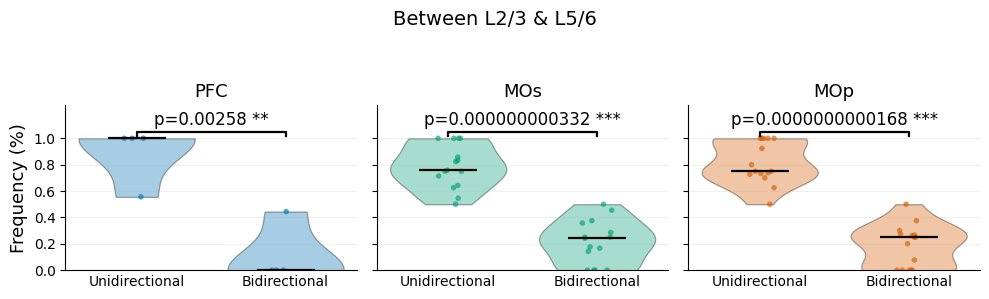

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================
# 0) 输入：你必须已经有 res（每行=一个clone，含 group + f_uni_* / f_bi_* 列）
# =========================
if "res" not in globals():
    raise NameError("你需要先运行前面的统计代码，得到 DataFrame: res")

dfp = res.copy()

# 顺序改成：PFC -> MOs -> MOp
dfp = dfp[dfp["group"].isin(["PFC", "MOs", "MOp"])].copy()
groups = ["PFC", "MOs", "MOp"]

# 配色（Okabe-Ito 风格）
palette = {"PFC": "#0072B2", "MOp": "#D55E00", "MOs": "#009E73"}
rng = np.random.default_rng(0)

def star(p):
    if not np.isfinite(p): return "NA"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# p：三位有效数字，但强制小数展示（不用科学计数法）

# =========================
# 1) 画图函数：每张图 3 个脑区子图；每子图 2 个 violin（Uni/Bi）
#    改动：
#    - 顺序：PFC -> MOs -> MOp
#    - 标题不显示 (n=xx)
#    - 只保留左/下坐标轴（去掉上/右）
#    - x轴不要刻度线（保留标签）
#    - y从0开始
#    - ns/NA：括号横线也不画（只对显著 p<0.05 画括号+文字）
#    - p：三位有效数字（小数展示）+ 星号
# =========================
def plot_three_regions(title, col_uni, col_bi, figsize=(16.0, 3.0), out_svg=None):
    need = ["group", col_uni, col_bi]
    miss = [c for c in need if c not in dfp.columns]
    if miss:
        print(f"[SKIP] {title}: res 缺少列 {miss}")
        return

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    fig.suptitle(title, fontsize=14)

    for ax, g in zip(axes, groups):
        dfg = dfp[dfp["group"] == g].copy()

        u = dfg[col_uni].astype(float).to_numpy()
        b = dfg[col_bi].astype(float).to_numpy()
        m = np.isfinite(u) & np.isfinite(b)   # 只保留 uni/bi 都有限的 clone
        x_uni = u[m]
        x_bi  = b[m]

        data = [x_uni, x_bi]
        pos = np.array([1.0, 2.0])

        # ---- violin ----
        vp = ax.violinplot(
            data, positions=pos, widths=0.78,
            showmeans=False, showmedians=True, showextrema=False
        )
        for body in vp["bodies"]:
            body.set_facecolor(palette[g])
            body.set_edgecolor("black")
            body.set_alpha(0.35)
            body.set_linewidth(0.9)
        vp["cmedians"].set_color("black")
        vp["cmedians"].set_linewidth(1.6)

        # ---- jitter 点 ----
        for i, y in enumerate(data):
            if y.size == 0:
                continue
            jitter = rng.uniform(-0.10, 0.10, size=y.size)
            ax.scatter(
                np.full(y.size, pos[i]) + jitter, y,
                s=16, alpha=0.65, color=palette[g], edgecolors="none"
            )

        # ---- x 轴：全称；不要刻度线 ----
        ax.set_xticks(pos)
        ax.set_xticklabels(["Unidirectional", "Bidirectional"])
        ax.tick_params(axis="x", which="both", length=0)

        # ---- y 轴：从0开始；上面留空间给显著性 ----
        ax.set_ylim(0.0, 1.25)
        yt = np.linspace(0.0, 1.0, 6)
        ax.set_yticks(yt)
        ax.set_yticklabels([f"{v:.1f}" for v in yt])

        # ---- 标题：只显示脑区名（不要 n=xx）----
        ax.set_title(f"{g}", fontsize=13)

        # ---- Welch t-test：Uni vs Bi ----
        p = np.nan
        if x_uni.size >= 2 and x_bi.size >= 2:
            p = float(ttest_ind(x_uni, x_bi, equal_var=False).pvalue)

        # ---- 仅显著才画括号 + 文本；ns/NA 连横线都不要 ----
        if np.isfinite(p) and (p < 0.05):
            y0 = 1.02
            h  = 0.03
            ax.plot([pos[0], pos[0], pos[1], pos[1]],
                    [y0, y0 + h, y0 + h, y0],
                    color="black", lw=1.6)

            p_str = format_p_decimal_3sig(p)
            ax.text(pos.mean(), y0 + h + 0.02,
                    f"p={p_str} {star(p)}",
                    ha="center", va="bottom", fontsize=12, color="black")

        ax.grid(axis="y", alpha=0.18)

        # ---- 只保留左/下坐标轴 ----
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Frequency (%)", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.90])

    if out_svg:
        fig.savefig(out_svg, bbox_inches="tight")

    plt.show()

# =========================
# 2) 依次画：All / L2/3内 / L5/6内 / 层间（并保存 svg）
# =========================
plot_three_regions("All nodes",          "f_uni_all",   "f_bi_all",   figsize=(10.0, 3),
                   out_svg="uni_bi_all.svg")
plot_three_regions("Within L2/3",        "f_uni_23",    "f_bi_23",    figsize=(10.0, 3),
                   out_svg="uni_bi_within_23.svg")
plot_three_regions("Within L5/6",        "f_uni_56",    "f_bi_56",    figsize=(10.0, 3),
                   out_svg="uni_bi_within_56.svg")
plot_three_regions("Between L2/3 & L5/6","f_uni_23_56", "f_bi_23_56", figsize=(10.0, 3),
                   out_svg="uni_bi_between_23_56.svg")

In [24]:
import math
import numpy as np
import pandas as pd
import torch

# ============================================================
# ===== 0) 你的 triad motif 计数器（只把 P 的初始化改成张量方式：逻辑等价，快很多）=====
# ============================================================

class motifRegular:
    def __init__(self, device="cpu", numOfNeuron=512, amplitude=1000, bias=0.05):
        if isinstance(device, str): device = torch.device(device)
        n = int(numOfNeuron)
        self.L = torch.ones((1, n), device=device)
        self.I = torch.eye(n, device=device)
        self.P = (torch.ones((n, n), device=device) - torch.eye(n, device=device))  # 等价于你原来的双重for
        self.obs = torch.zeros((14,), device=device)
        self.sum = combination(n, 3)
        self.recordSum = 0
        self.amplitude = amplitude
        self.bias = bias
        self.device = device

    def cal(self, a):
        w = torch.where(a > 0.0, torch.ones_like(a), torch.zeros_like(a))
        w = w * self.P
        pmw = self.P - w

        w0 = pmw * pmw.T
        w1 = w   * pmw.T
        w2 = pmw * w.T
        w3 = w   * w.T

        q = torch.zeros((14,), dtype=torch.float32, device=self.device)

        q[1]  = 0.5 * self.L @ (w1 * (w1 @ w0)) @ self.L.T
        q[2]  = 0.5 * self.L @ (w0 * (w1 @ w2)) @ self.L.T
        q[3]  =       self.L @ (w1 * (w0 @ w2)) @ self.L.T
        q[4]  =       self.L @ (w1 * (w1 @ w2)) @ self.L.T

        q[5]  =       self.L @ (w3 * (w1 @ w0)) @ self.L.T
        q[6]  =       self.L @ (w3 * (w2 @ w0)) @ self.L.T
        q[7]  = 0.5 * self.L @ (w3 * (w1 @ w2)) @ self.L.T
        q[8]  = 0.5 * self.L @ (w3 * (w2 @ w1)) @ self.L.T

        q[9]  = 0.5 * self.L @ (w3 * (w3 @ w0)) @ self.L.T
        q[10] = (1.0/3.0) * self.L @ (w1 * (w2 @ w2)) @ self.L.T
        q[11] =       self.L @ (w3 * (w2 @ w2)) @ self.L.T
        q[12] =       self.L @ (w3 * (w3 @ w2)) @ self.L.T
        q[13] = (1.0/6.0) * self.L @ (w3 * (w3 @ w3)) @ self.L.T

        return q[1:14].flatten()  # (13,)

# ============================================================
# ===== 1) 读数据（按你现有文件名）=====
# ============================================================
sc_path    = "wb_alltype_sc_subset_zj_1_2.5_42_1209.npy"
names_path = "wb_alltype_sc_subset_names_zj_1_2.5_42_1209.npy"
csv_path   = "Metadata_PFC_MOp.csv"

sc = np.load(sc_path)
names = np.load(names_path, allow_pickle=True)
names = names.tolist() if isinstance(names, np.ndarray) else list(names)
names = np.asarray([str(x) for x in names], dtype=str)

df = pd.read_csv(csv_path)

# ============================================================
# ===== 2) 列名兼容 + 对齐到 sc/names 顺序 =====
# ============================================================
id_col = "name" if "name" in df.columns else ("Unnamed: 0" if "Unnamed: 0" in df.columns else None)
if id_col is None: raise ValueError("CSV 里找不到 neuron id 列（name / Unnamed: 0）。")

clone_region_col = None
for cand in ["Clone_region", "clone_region", "CLONE_REGION"]:
    if cand in df.columns: clone_region_col = cand; break
if clone_region_col is None: raise ValueError("CSV 里找不到 Clone_region 列。")
if "clone" not in df.columns or "Layer" not in df.columns: raise ValueError("CSV 缺少 clone 或 Layer 列。")

meta = df.copy()
meta[id_col] = meta[id_col].astype(str)
meta = meta.set_index(id_col)

clone_arr  = meta.reindex(names)["clone"].to_numpy()
region_arr = meta.reindex(names)[clone_region_col].astype(str).to_numpy()

valid = ~pd.isna(clone_arr)
print(f"总节点数: {len(names)} | clone 匹配到: {int(valid.sum())} | clone数: {pd.unique(clone_arr[valid]).size}")

# ============================================================
# ===== 3) 神经元级别：Clone_region -> 三脑区（与你之前一致口径）=====
# ============================================================
group_arr = np.full(len(names), np.nan, dtype=object)
r = pd.Series(region_arr.astype(str))
mask_pfc = r.str.startswith(("ACA", "PL", "FRP", "ORB"))
mask_mop = r.str.startswith("MOp")
mask_mos = r.str.startswith("MOs")
group_arr[mask_pfc.to_numpy()] = "PFC"
group_arr[mask_mop.to_numpy()] = "MOp"
group_arr[mask_mos.to_numpy()] = "MOs"

# ============================================================
# ===== 4) 三脑区：整体 motif / clone内 motif / clone间 motif（=整体-内）=====
# ============================================================
device = "cpu"
thr = 0.0
motif_names = [f"Motif {i}" for i in range(1, 14)]
out_rows = []

for g in ["PFC", "MOp", "MOs"]:
    idx_g = np.flatnonzero(valid & (group_arr == g))
    n_g = int(idx_g.size)
    print(f"\n[{g}] 节点数 n={n_g}")
    if n_g < 3:
        print(f"[{g}] n<3，无法算 triad motif，跳过")
        continue

    # ---------- 4.1 脑区整体 motif ----------
    A_g = sc[np.ix_(idx_g, idx_g)].astype(np.float32, copy=False)
    np.fill_diagonal(A_g, 0.0)
    mr_g = motifRegular(device=device, numOfNeuron=n_g)
    real_g = mr_g.cal(torch.from_numpy(A_g).to(mr_g.device)).detach().cpu().numpy().astype(float)

    # ---------- 4.2 脑区内：clone 内 motif（对每个 clone 子图算 motif 后求和）----------
    clone_g = clone_arr[idx_g]
    clones = pd.unique(clone_g)
    in_g = np.zeros(13, dtype=float)
    cn3_in = 0  # 记录 clone 内 triad 数（可选展示）
    for cl in clones:
        idx_local = np.flatnonzero(clone_g == cl)   # 在 idx_g 的局部索引
        if idx_local.size < 3:
            continue
        idx_cl = idx_g[idx_local]                  # 回到全局索引
        A_cl = sc[np.ix_(idx_cl, idx_cl)].astype(np.float32, copy=False)
        np.fill_diagonal(A_cl, 0.0)
        mr_cl = motifRegular(device=device, numOfNeuron=int(idx_local.size))
        in_g += mr_cl.cal(torch.from_numpy(A_cl).to(mr_cl.device)).detach().cpu().numpy().astype(float)
        cn3_in += combination(int(idx_local.size), 3)

    # ---------- 4.3 clone 间 motif（整体 - clone 内）----------
    between_g = real_g - in_g

    # ---------- 4.4 汇总输出 ----------
    cn3_total = combination(n_g, 3)
    out_rows.append({
        "group": g, "n_nodes": n_g, "cn3_total": cn3_total, "cn3_within_clone_sum": cn3_in,
        **{f"real_{m}": real_g[i] for i, m in enumerate(motif_names)},
        **{f"withinClone_{m}": in_g[i] for i, m in enumerate(motif_names)},
        **{f"betweenClone_{m}": between_g[i] for i, m in enumerate(motif_names)},
    })

res_motif = pd.DataFrame(out_rows)

# ============================================================
# ===== 5) 展示：每脑区一个 13×3 表（real / withinClone / betweenClone）=====
# ============================================================
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 200)

for g in res_motif["group"].tolist():
    row = res_motif[res_motif["group"] == g].iloc[0]
    show = pd.DataFrame({
        "motif": motif_names,
        "real": [row[f"real_{m}"] for m in motif_names],
        "withinClone": [row[f"withinClone_{m}"] for m in motif_names],
        "betweenClone": [row[f"betweenClone_{m}"] for m in motif_names],
    })
    print(f"\n================ {g} ================")
    print(f"n={int(row['n_nodes'])} | C(n,3)={int(row['cn3_total'])} | sum C(n_clone,3)={int(row['cn3_within_clone_sum'])}")
    print(show.to_string(index=False))

print("\n✅ Done. 已在终端打印每个脑区的 real / clone内 / clone间 (real - clone内) motif 计数。")

总节点数: 751 | clone 匹配到: 751 | clone数: 92

[PFC] 节点数 n=140

[MOp] 节点数 n=333

[MOs] 节点数 n=269

================ PFC ================
n=140 | C(n,3)=447580 | sum C(n_clone,3)=1340
   motif  real  withinClone  betweenClone
 Motif 1 351.0         36.0         315.0
 Motif 2 310.0         29.0         281.0
 Motif 3 653.0         59.0         594.0
 Motif 4 114.0         32.0          82.0
 Motif 5 388.0         73.0         315.0
 Motif 6 311.0         48.0         263.0
 Motif 7  72.0         32.0          40.0
 Motif 8  68.0         18.0          50.0
 Motif 9  52.0         25.0          27.0
Motif 10  22.0          2.0          20.0
Motif 11  47.0         21.0          26.0
Motif 12  96.0         73.0          23.0
Motif 13  38.0         32.0           6.0

================ MOp ================
n=333 | C(n,3)=6099006 | sum C(n_clone,3)=3256
   motif         real  withinClone  betweenClone
 Motif 1 13213.000000        153.0  13060.000000
 Motif 2  7058.000000         98.0   6960.000000
 Mo

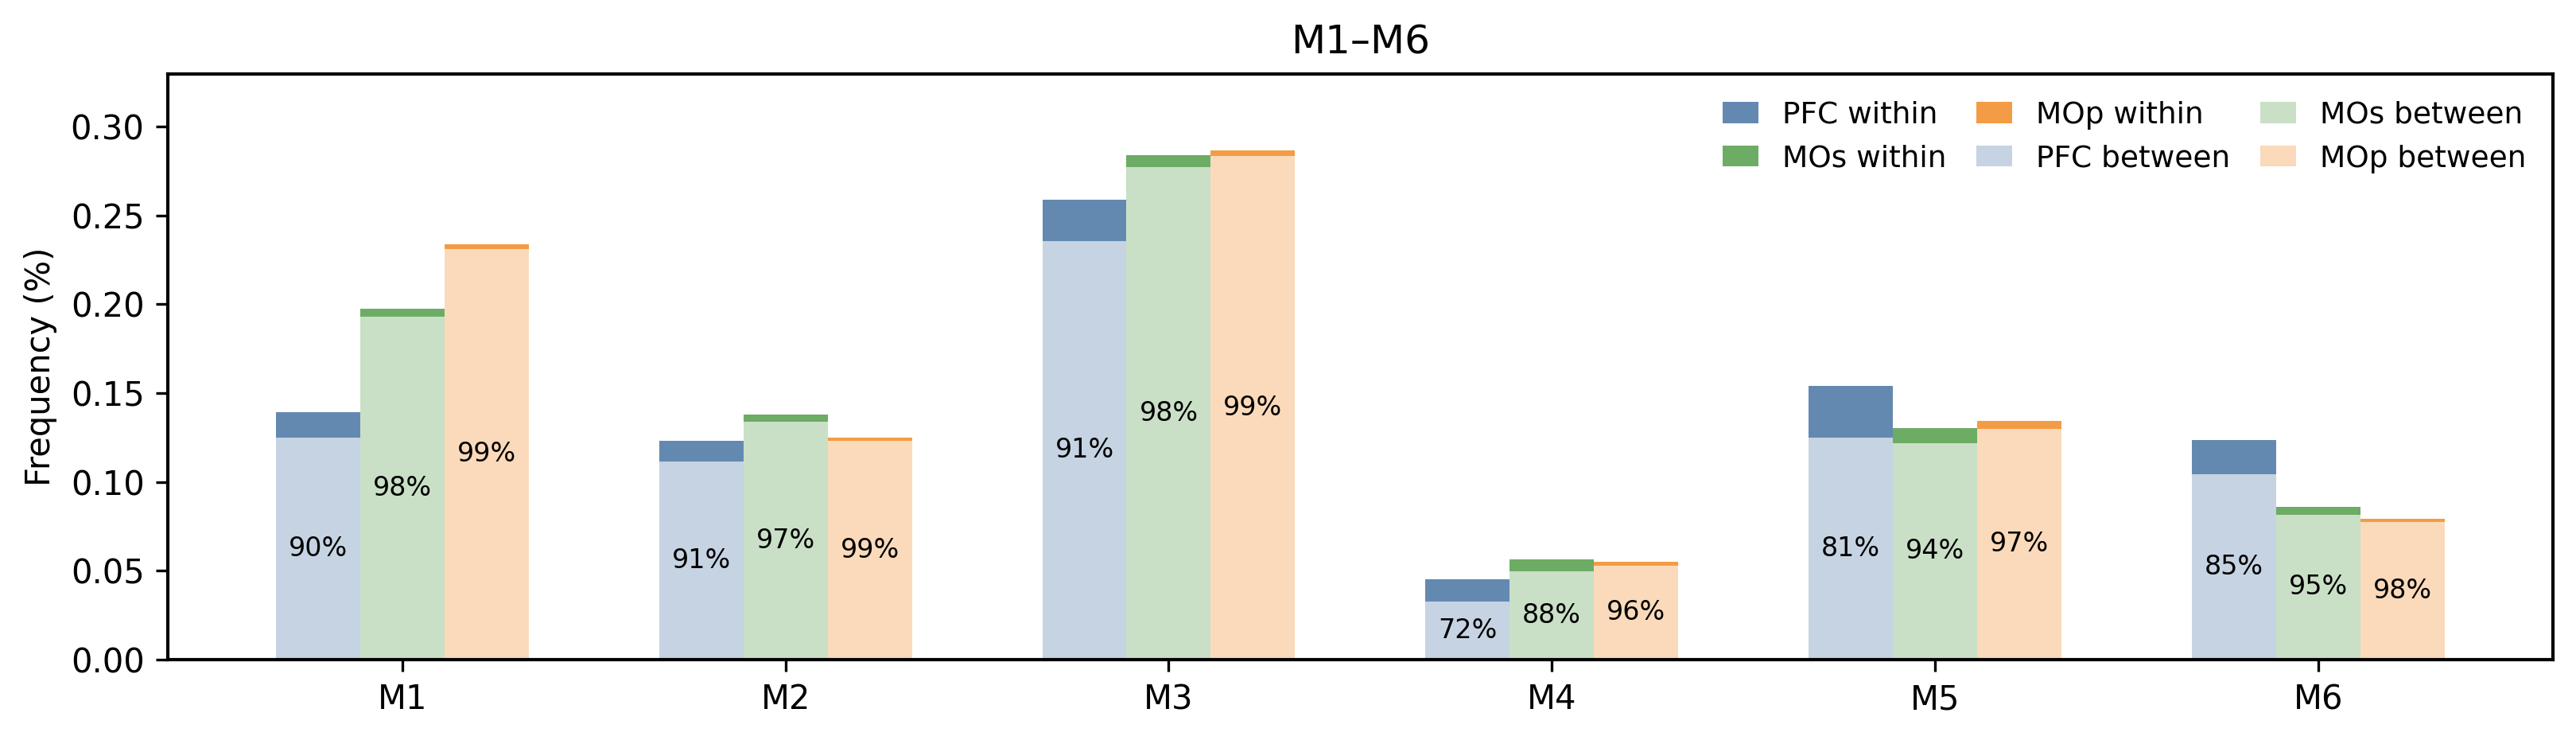

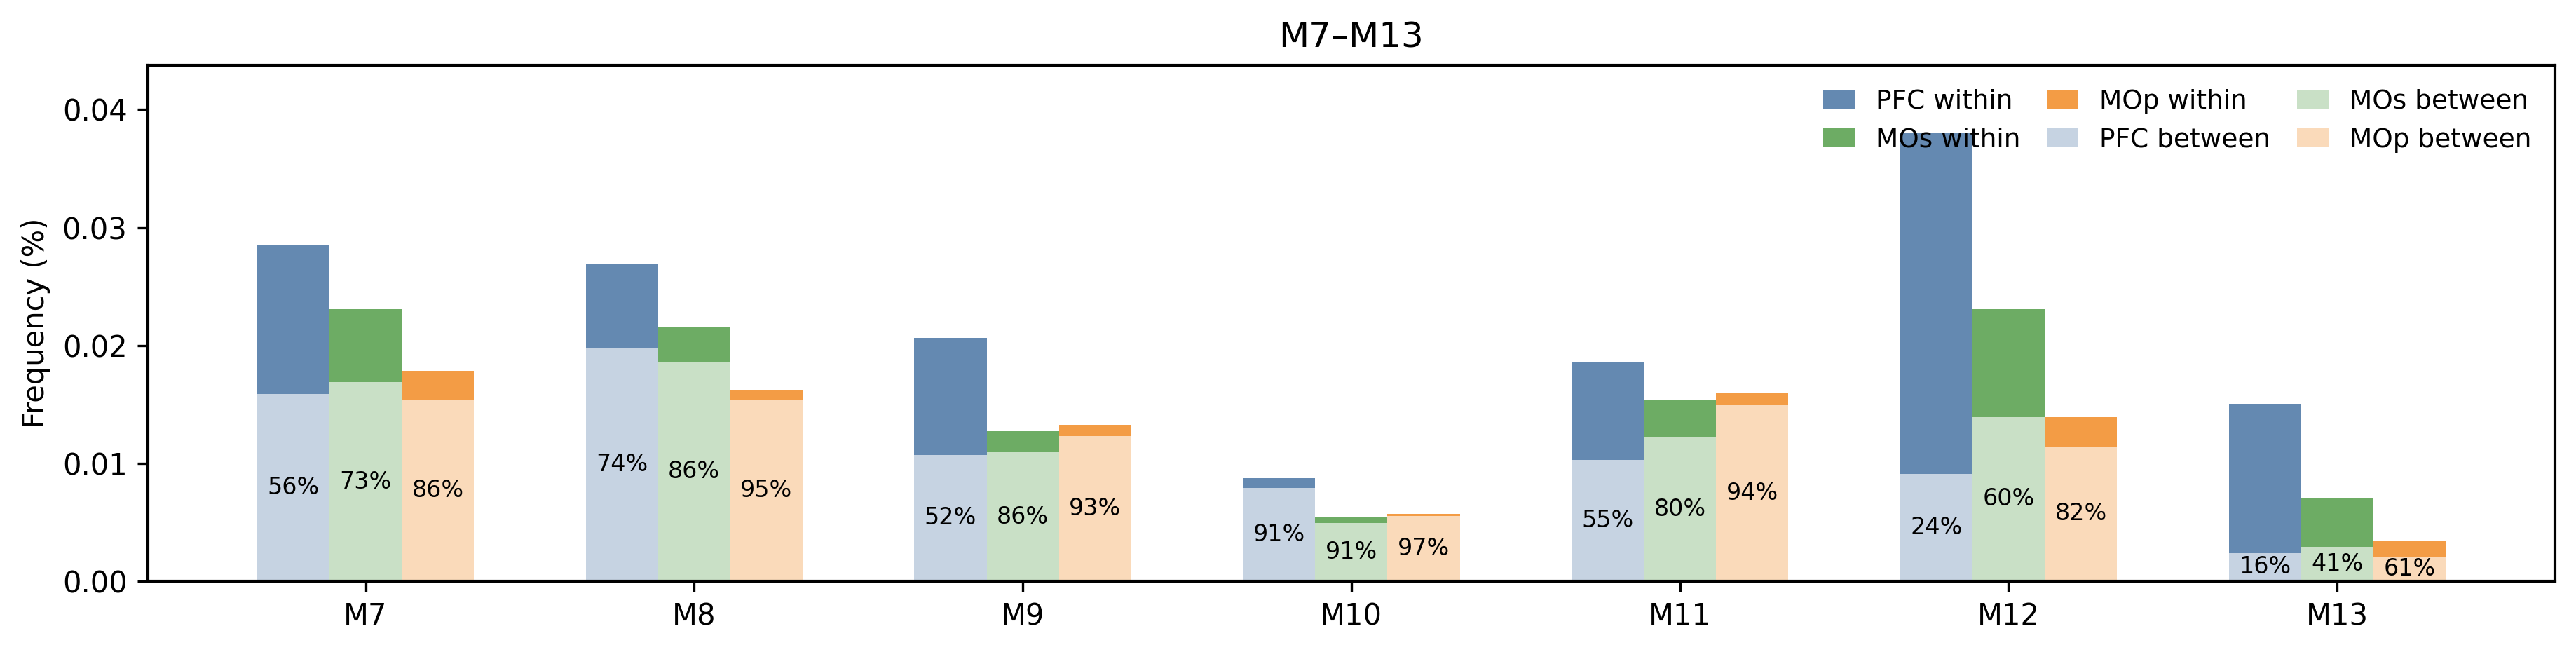

✅ Saved: motif_prop_M1-6.svg, motif_prop_M7-13.svg


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

# =========================
# ===== 0) 基础检查 =====
# =========================
if "res_motif" not in globals():
    raise NameError("需要先有 DataFrame: res_motif（含 group + real_/withinClone_/betweenClone_ 的 13 motif 列）")

df = res_motif.copy()

# 顺序：PFC -> MOs -> MOp（和你之前一致的话也更统一）
groups = ["PFC", "MOs", "MOp"]
df = df[df["group"].isin(groups)].copy()
if df.empty:
    raise ValueError("res_motif 里没有 PFC/MOs/MOp 行，请检查 group 映射。")

# =========================
# ===== 1) 论文风格 =====
# =========================
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 10,
    "axes.linewidth": 1.0,
})

# 三色（偏柔和）
palette = {
    "PFC": "#4E79A7",  # soft blue
    "MOp": "#F28E2B",  # warm orange
    "MOs": "#59A14F",  # soft green
}

# 你的要求：clone内=深色；clone间=浅色
alpha_within  = 0.88  # 深
alpha_between = 0.32  # 浅

motif_names = [f"Motif {i}" for i in range(1, 14)]

# =========================
# ===== 2) 取数 + 归一化 =====
#     归一化口径：real / sum(real over 13 motifs)
# =========================
real_mat    = np.full((len(groups), 13), np.nan, float)
within_mat  = np.full((len(groups), 13), np.nan, float)
between_mat = np.full((len(groups), 13), np.nan, float)

for gi, g in enumerate(groups):
    row = df[df["group"] == g]
    if row.shape[0] != 1:
        raise ValueError(f"group={g} 在 res_motif 里行数不是 1（当前={row.shape[0]}），请先确保每脑区只保留一行汇总。")
    row = row.iloc[0]

    real    = np.array([float(row[f"real_{m}"]) for m in motif_names], dtype=float)
    within  = np.array([float(row[f"withinClone_{m}"]) for m in motif_names], dtype=float)
    between = np.array([float(row[f"betweenClone_{m}"]) for m in motif_names], dtype=float)

    den = np.sum(real)
    den = np.nan if (not np.isfinite(den) or den == 0) else den

    real_mat[gi]    = real / den
    within_mat[gi]  = within / den
    between_mat[gi] = between / den

# =========================
# ===== 3) 分图绘制：1-6 / 7-13 =====
# =========================
blocks = [
    (range(1, 7),   "M1–M6",   "motif_prop_M1-6.svg"),
    (range(7, 14),  "M7–M13",  "motif_prop_M7-13.svg"),
]

for ids, title, out_svg in blocks:
    idx = np.array([i - 1 for i in ids], dtype=int)
    x = np.arange(len(idx), dtype=float)

    w = 0.22
    offsets = np.array([-w, 0.0, w], dtype=float)

    fig_w = 1.45 * len(idx) + 2.2
    fig, ax = plt.subplots(figsize=(fig_w, 3.2))

    # ---- 柱子：同色堆叠（clone间浅色在下，clone内深色在上）----
    for gi, g in enumerate(groups):
        xx = x + offsets[gi]
        col = palette[g]

        ax.bar(xx, between_mat[gi, idx], width=w, color=col, alpha=alpha_between, linewidth=0)
        ax.bar(xx, within_mat[gi, idx],  width=w, bottom=between_mat[gi, idx], color=col, alpha=alpha_within, linewidth=0)

        # 百分比文字：within / (within+between) 或 between/(sum) 你之前是 between占比；这里保持 between占比
        tot = within_mat[gi, idx] + between_mat[gi, idx]
        pct = np.where(tot > 0, (between_mat[gi, idx] / tot) * 100.0, np.nan)
        for j in range(len(idx)):
            if np.isfinite(pct[j]) and np.isfinite(between_mat[gi, idx][j]) and between_mat[gi, idx][j] > 0:
                ax.text(xx[j], 0.5 * between_mat[gi, idx][j], f"{pct[j]:.0f}%",
                        ha="center", va="center", fontsize=8, color="black")

    # ---- x轴 ----
    ax.set_xticks(x)
    ax.set_xticklabels([f"M{i}" for i in ids])

    # ---- y轴：每图自适应（用 real_mat 做参考）----
    ymax = np.nanmax(real_mat[:, idx])
    ymax = 0.02 if (not np.isfinite(ymax) or ymax <= 0) else ymax
    ax.set_ylim(0.0, ymax * 1.15)

    ax.set_title(title)
    ax.set_ylabel("Frequency (%)")

    # =========================
    # Legend：两排（脑区*clone内/间）
    # 第一排：within-clone（深色）
    # 第二排：between-clone（浅色）
    # =========================
    handles_within = [
        mpatches.Patch(facecolor=palette[g], edgecolor="none", alpha=alpha_within, label=f"{g} within")
        for g in groups
    ]
    handles_between = [
        mpatches.Patch(facecolor=palette[g], edgecolor="none", alpha=alpha_between, label=f"{g} between")
        for g in groups
    ]
    handles = handles_within + handles_between

    ax.legend(handles=handles, frameon=False, ncol=3, loc="upper right",
              fontsize=9, handlelength=1.2, columnspacing=1.0)

    fig.tight_layout()
    fig.savefig(out_svg, format="svg", bbox_inches="tight", transparent=True)
    plt.show()

print("✅ Saved:", ", ".join([b[2] for b in blocks]))